In [75]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, models, regularizers ,callbacks

import joblib

from utils import set_seed
set_seed(42)

 Random seed зафиксирован: 42


# Подготовка данных

In [76]:
df_features = pd.read_csv('data/features.csv')

target_col = 'consumption'
feature_cols = [col for col in df_features.columns if col not in ['timestamp', target_col]]

split_idx = int(len(df_features) * 0.8)
train_df = df_features.iloc[:split_idx].copy()
test_df = df_features.iloc[split_idx:].copy()

scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_df[feature_cols])
test_X_scaled = scaler_X.transform(test_df[feature_cols])

train_y = train_df[target_col].values
test_y = test_df[target_col].values

train_dates = pd.to_datetime(train_df['timestamp']).values
test_dates = pd.to_datetime(test_df['timestamp']).values

SEQ_LEN = 24  
HORIZON = 24   

def create_sequences(X_data, y_data, dates_array, seq_len, horizon):
    X, y, dates = [], [], []
    for i in range(len(X_data) - seq_len - horizon + 1):
        X.append(X_data[i : i + seq_len])
        
        y_window = y_data[i + seq_len : i + seq_len + horizon]
        y.append(np.log1p(y_window)) 
        
        dates.append(dates_array[i + seq_len]) 
    return np.array(X), np.array(y), np.array(dates)

X_train, y_train, dates_train = create_sequences(train_X_scaled, train_y, train_dates, SEQ_LEN, HORIZON)
X_test, y_test, dates_test = create_sequences(test_X_scaled, test_y, test_dates, SEQ_LEN, HORIZON)

print(f"Формат X_train: {X_train.shape} - (Samples, SEQ_LEN, Features)")
print(f"Формат y_train: {y_train.shape} - (Samples, HORIZON)")
print(f"Формат X_test:  {X_test.shape}")

Формат X_train: (6825, 24, 57) - (Samples, SEQ_LEN, Features)
Формат y_train: (6825, 24) - (Samples, HORIZON)
Формат X_test:  (1672, 24, 57)


# Cтандартизация признаков X

In [77]:
n_features = X_train.shape[2]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, 'model_weights/scaler_gru.joblib')

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")

X_train_scaled shape: (6825, 24, 57)
y_train shape: (6825, 24)


# Кастомная функция потерь 

In [78]:

@tf.keras.utils.register_keras_serializable() 
def asymmetric_profit_loss(y_true, y_pred):
    """
    Штрафует сильнее за недопрогноз (когда y_true > y_pred).
    Это заставляет модель предсказывать пики потребления с запасом.
    """
    error = y_true - y_pred
    penalty_under = 3.0 
    penalty_over = 1.0
    
    loss = tf.where(error > 0, 
                    tf.square(error) * penalty_under, 
                    tf.square(error) * penalty_over)
    
    return tf.reduce_mean(loss)



# Архитектура модели

In [79]:
n_features = X_train_scaled.shape[2]

model_gru = models.Sequential([
    layers.Input(shape=(SEQ_LEN, n_features)),
    
    layers.GRU(128, return_sequences=True, activation='tanh',
               kernel_regularizer=regularizers.l2(1e-5)), 
    layers.LayerNormalization(), 
    
    layers.GRU(64, return_sequences=False, activation='tanh',
               kernel_regularizer=regularizers.l2(1e-5)),
    layers.LayerNormalization(), 
    
    layers.Dense(64, activation='swish'),
    
    layers.Dense(32, activation='swish'),
    
    layers.Dense(HORIZON, activation='linear')
])

In [ ]:
model_gru.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipvalue=0.5), 
    loss=asymmetric_profit_loss, 
    metrics=['mae']
)

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=20, 
        restore_best_weights=True, 
        verbose=1
    ),
    
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.75, 
        patience=10, 
        min_lr=1e-6, 
        verbose=1
    ),
    callbacks.TerminateOnNaN()
]

model_gru.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_18 (GRU)                    │ (None, 24, 128)        │        71,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_18          │ (None, 24, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_19 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_19          │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,472 (454.97 KB)

 Trainable params: 116,472 (454.97 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
history_gru = model_gru.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 223.1711 - mae: 6.6712 - val_loss: 0.2107 - val_mae: 0.3064 - learning_rate: 0.0010
Epoch 2/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1171 - mae: 0.2442 - val_loss: 0.0911 - val_mae: 0.2127 - learning_rate: 0.0010
Epoch 3/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0834 - mae: 0.2027 - val_loss: 0.0723 - val_mae: 0.1824 - learning_rate: 0.0010
Epoch 4/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0648 - mae: 0.1736 - val_loss: 0.0553 - val_mae: 0.1480 - learning_rate: 0.0010
Epoch 5/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0514 - mae: 0.1510 - val_loss: 0.0407 - val_mae: 0.1361 - learning_rate: 0.0010
Epoch 6/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0395 - mae: 0.1298 - val_loss: 0.0337 - val_mae: 0.1293 - learning_rate: 0.0010
Epoch 7/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0324 - mae: 0.1159 - val_loss: 0.0267 - val_mae: 0.1120 - learning_rate: 0.0010
Epoc

# График обучения

In [82]:
def plot_training_history(history, start_epoch=5):
    """
    Визуализация истории обучения, пропуская первые эпохи для лучшего масштаба.
    """
    s = start_epoch - 1
    
    epochs = range(s + 1, len(history.history['loss']) + 1)
    
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # ГРАФИК 1: LOSS (Asymmetric Profit Loss) 
    ax[0].plot(epochs, history.history['loss'][s:], label='Train Loss', color='steelblue', linewidth=2)
    ax[0].plot(epochs, history.history['val_loss'][s:], label='Val Loss', color='darkorange', linewidth=2, linestyle='--')
    ax[0].set_title(f'История Loss (с {start_epoch} эпохи)', fontsize=13, fontweight='bold')
    ax[0].set_xlabel('Эпоха')
    ax[0].set_ylabel('Value')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # ГРАФИК 2: MAE 
    ax[1].plot(epochs, history.history['mae'][s:], label='Train MAE', color='forestgreen', linewidth=2)
    ax[1].plot(epochs, history.history['val_mae'][s:], label='Val MAE', color='crimson', linewidth=2, linestyle='--')
    ax[1].set_title(f'История MAE (с {start_epoch} эпохи)', fontsize=13, fontweight='bold')
    ax[1].set_xlabel('Эпоха')
    ax[1].set_ylabel('MAE (Вт/лог)')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('data/12_gru_training_history.png', dpi=150, bbox_inches='tight')


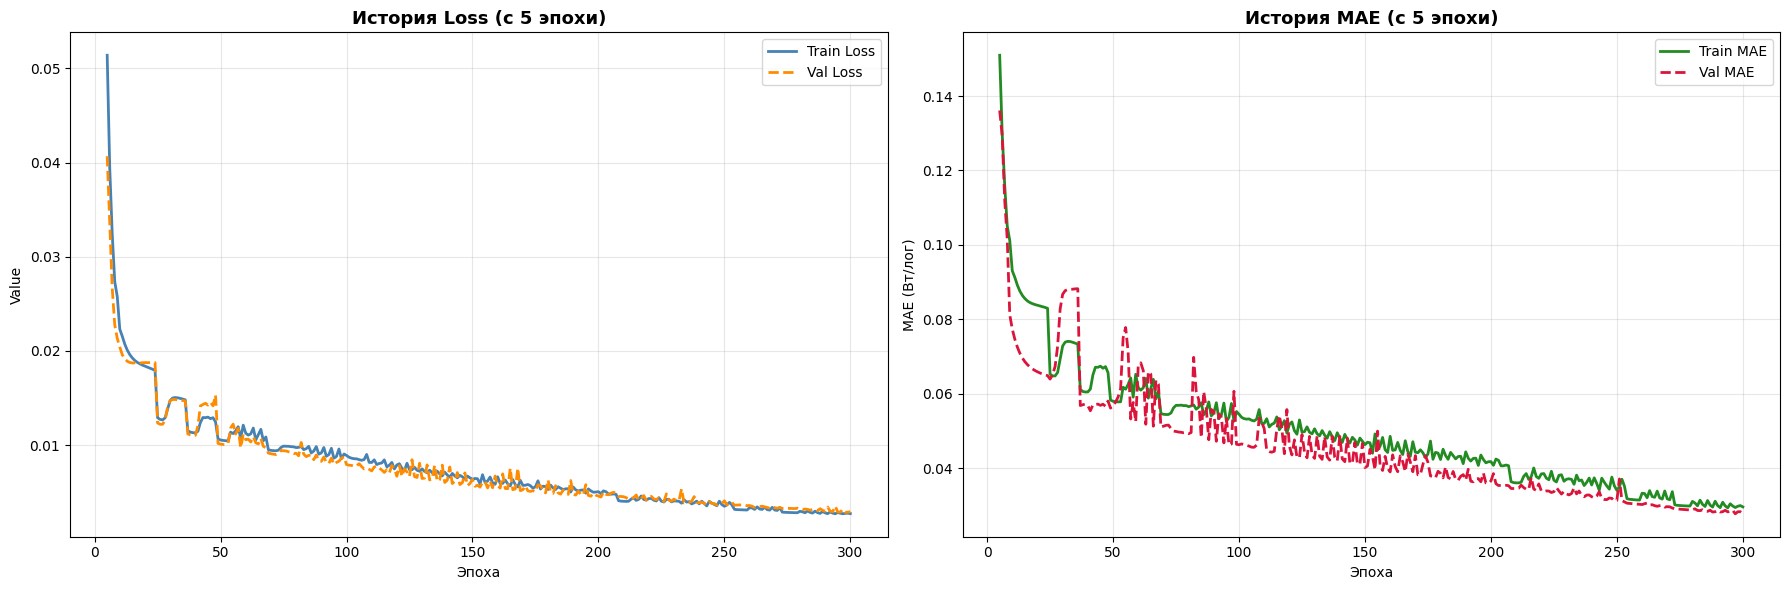

In [83]:
if len(history_gru.history['loss']) > 5:
    plot_training_history(history_gru, start_epoch=5)
else:
    print("Обучение длилось меньше 5 эпох, вывод графика невозможен.")

# График предсказаний

In [84]:
y_pred_log = model_gru.predict(X_test_scaled, verbose=0)

y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)


MAE:   128303.11 Вт
RMSE:  173738.72 Вт
MAPE:       3.66 %
R2:       0.9687


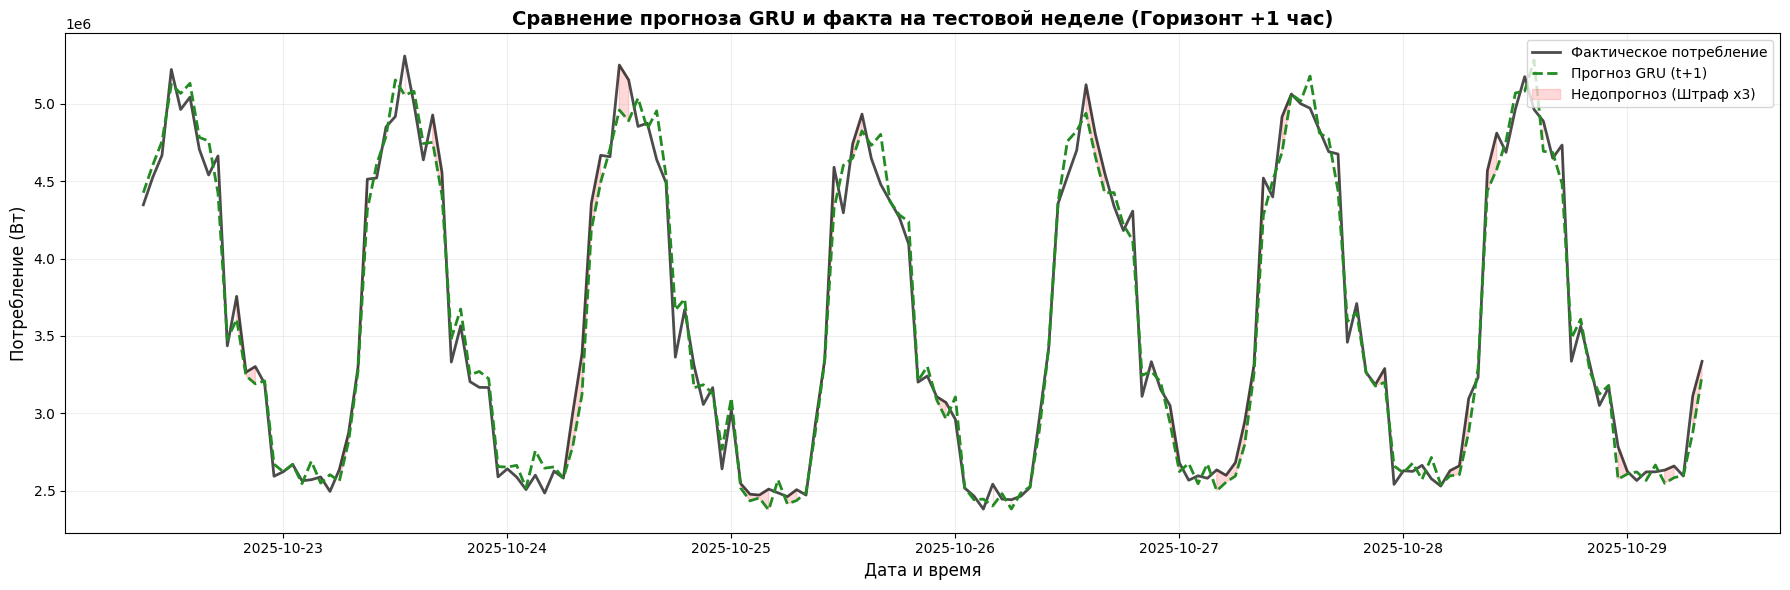

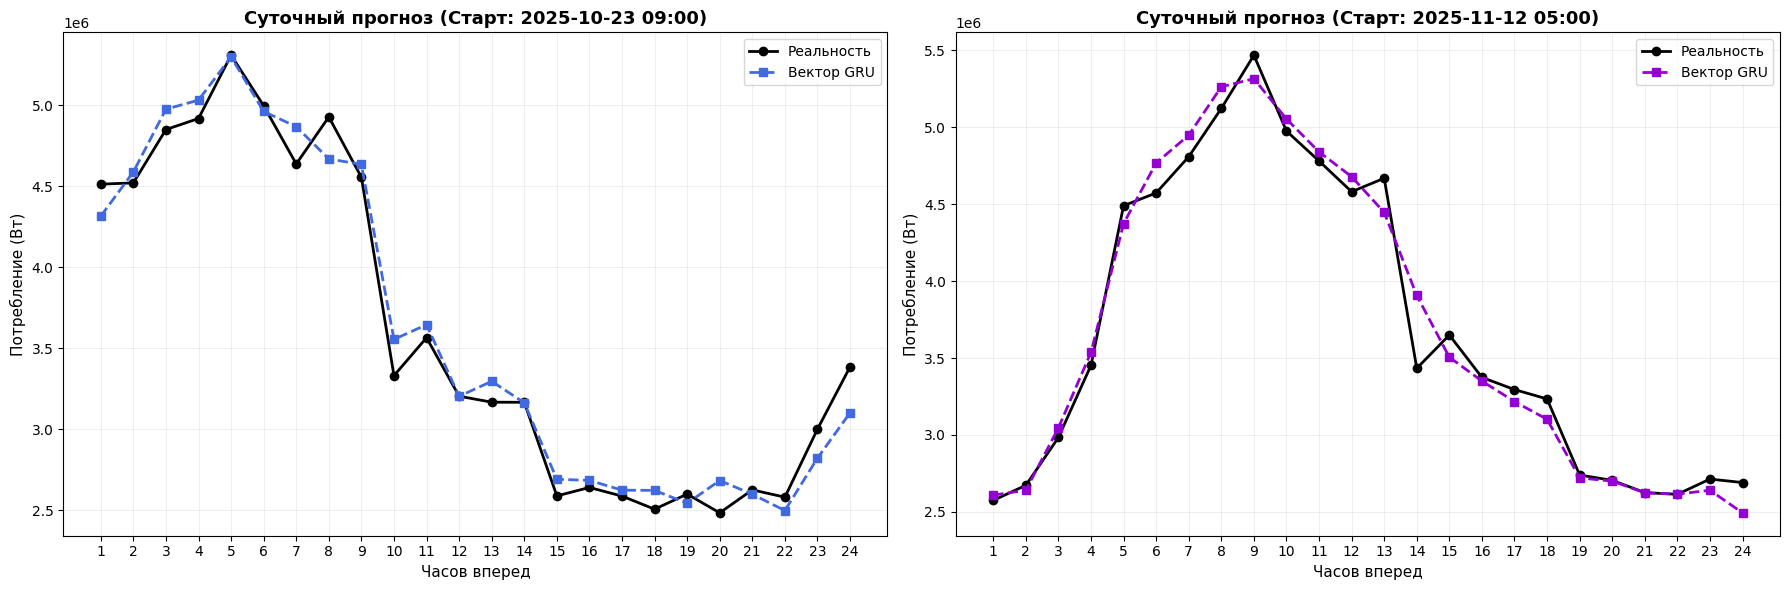

In [85]:

n_hours = 168 
step_idx = 0 

plt.figure(figsize=(18, 6))
plt.plot(dates_test[:n_hours], y_test_real[:n_hours, step_idx], 
         label='Фактическое потребление', color='black', linewidth=2, alpha=0.7)
plt.plot(dates_test[:n_hours], y_pred_real[:n_hours, step_idx], 
         label='Прогноз GRU (t+1)', color='forestgreen', linewidth=2, linestyle='--')

plt.fill_between(dates_test[:n_hours], y_test_real[:n_hours, step_idx], y_pred_real[:n_hours, step_idx], 
                 where=(y_test_real[:n_hours, step_idx] > y_pred_real[:n_hours, step_idx]),
                 color='red', alpha=0.15, label='Недопрогноз (Штраф x3)')

plt.title(f'Сравнение прогноза GRU и факта на тестовой неделе (Горизонт +1 час)', fontsize=14, fontweight='bold')
plt.xlabel('Дата и время', fontsize=12)
plt.ylabel('Потребление (Вт)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sample_indices = [24, 500] 
colors = ['royalblue', 'darkviolet']

for i, idx in enumerate(sample_indices):
    hours_ahead = np.arange(1, 25)
    ax[i].plot(hours_ahead, y_test_real[idx], label='Реальность', color='black', marker='o', linewidth=2)
    ax[i].plot(hours_ahead, y_pred_real[idx], label='Вектор GRU', color=colors[i], marker='s', linestyle='--', linewidth=2)
    
    start_time = pd.to_datetime(dates_test[idx]).strftime('%Y-%m-%d %H:00')
    ax[i].set_title(f'Суточный прогноз (Старт: {start_time})', fontsize=13, fontweight='bold')
    ax[i].set_xlabel('Часов вперед', fontsize=11)
    ax[i].set_ylabel('Потребление (Вт)', fontsize=11)
    ax[i].set_xticks(hours_ahead)
    ax[i].grid(True, alpha=0.2)
    ax[i].legend()

plt.tight_layout()
mae_overall = mean_absolute_error(y_test_real, y_pred_real)
rmse_overall = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

mape_overall = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
r2_overall = r2_score(y_test_real, y_pred_real)

print(f"MAE:  {mae_overall:>10.2f} Вт")
print(f"RMSE: {rmse_overall:>10.2f} Вт")
print(f"MAPE: {mape_overall:>10.2f} %")
print(f"R2:   {r2_overall:>10.4f}")

# Сохранение весов

In [86]:
model_gru.save('model_weights/gru_model.keras')